## Supervised Research (Law, Economics, and Data Science)
#### Project name "Anomaly Detection for CNP Transactions".

Student: Anna Kravchenko

akravchenko@student.ethz.ch

### Part 4 - Modelling

## Goal

This notebook treats fraud detection as anomaly ranking with top-K alerting, where unsupervised detectors (Isolation Forest, a small Autoencoder) are the main focus, and a single calibrated supervised model is included only as a labeled reference point, not the main event. 

Evaluation is built around a fixed daily alert budget, where what matters is Precision@K, Recall@K, and analyst workload, not a single leaderboard metric like ROC-AUC. 

This notebook is built around that:

- Isolation Forest and a small tabular Autoencoder (reconstruction error as the anomaly score) are the primary, unsupervised detectors trained on transaction/behavioral features only, never on isFraud.
A single calibrated LightGBM model (isotonic calibration fit on `val`, applied to `holdout`) is included as a labeled reference, not blended with a second model.
- Precision@K/Recall@K is computed per day on the holdout window, for fixed K = 50/100/200 and a fixed alert-rate variant that scales with daily volume, along with alerts per 1,000 transactions and estimated analyst-hours.
- PR-AUC is used as the main ranking metric. ROC-AUC is reported too, but only as a secondary number (it does not reflect how well the model performs once only the top-K alerts are actually reviewed).   
- SHAP gives global feature importance plus short case notes on a few individual high-scored holdout alerts, for the calibrated reference model.
- A final alert-budget recommendation is given for two staffing scenarios. 

### Imports and setup

In [9]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 200)

### Paths

In [10]:
PROJECT_DIR = Path.cwd()
ART_DIR = PROJECT_DIR / 'artifacts'
PROC_DIR = PROJECT_DIR / 'processed'
MODEL_DIR = PROJECT_DIR / 'models'
PRED_DIR = PROJECT_DIR / 'predictions'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)
(PRED_DIR / 'figures').mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
if not (PROC_DIR / 'train_processed_gbm.parquet').exists():
    raise FileNotFoundError(
        f"processed/train_processed_gbm.parquet not found under {PROJECT_DIR}. Either "
        "Jupyter's working directory is not the project root (relaunch it from the project "
        "folder, or run os.chdir(r'<project folder path>') above), or Part 3 hasn't been run "
        "yet -- run Parts 1-3 first."
    )

PROJECT_DIR: /Users/kravchan/Downloads/Supervised Research/project


### Load processed data

Two feature branches from Part 3: the label-encoded one for the calibrated GBM reference, and the one-hot + frequency-encoded + standardized one for Isolation Forest / the Autoencoder. Both share the same `TransactionID`, `isFraud`, `event_time`, and chronological `split` column.

In [11]:
gbm_df = pd.read_parquet(PROC_DIR / 'train_processed_gbm.parquet')
ifae_df = pd.read_parquet(PROC_DIR / 'train_processed_ifae.parquet')
gbm_df['event_time'] = pd.to_datetime(gbm_df['event_time'])
ifae_df['event_time'] = pd.to_datetime(ifae_df['event_time'])
#these columns are id/label/bookkeeping, not real model inputs
exclude = {'TransactionID', 'isFraud', 'event_time', 'split'}
#everything else in each dataframe counts as a model feature
gbm_feats = [c for c in gbm_df.columns if c not in exclude]
ifae_feats = [c for c in ifae_df.columns if c not in exclude]
#boolean masks for each split, used to slice the data throughout this notebook
is_train = (gbm_df['split'] == 'train').values
is_val = (gbm_df['split'] == 'val').values
is_ho = (gbm_df['split'] == 'holdout').values
y = gbm_df['isFraud'].astype(int).values

print('GBM branch:', gbm_df.shape, '|', len(gbm_feats), 'features')
print('IF/AE branch:', ifae_df.shape, '|', len(ifae_feats), 'features')
print('split sizes -> train:', is_train.sum(), ' val:', is_val.sum(), ' holdout:', is_ho.sum())
print('fraud rate -> train:', y[is_train].mean().round(4), ' val:', y[is_val].mean().round(4), ' holdout:', y[is_ho].mean().round(4))

GBM branch: (590540, 196) | 192 features
IF/AE branch: (590540, 377) | 373 features
split sizes -> train: 354324  val: 118108  holdout: 118108
fraud rate -> train: 0.0338  val: 0.039  holdout: 0.0344


## Isolation Forest (primary, unsupervised)

Fit on the standardized one-hot IF/AE feature branch, `train`-split rows only, `isFraud` never touched. 
The anomaly score is `-score_samples` (higher=more anomalous, consistent with the other two model's scoring convention below).

In [12]:
Xi = ifae_df[ifae_feats].astype('float32').values

t0 = time.time()
iso_forest = IsolationForest(
    n_estimators=150,
    max_samples=min(65536, int(is_train.sum())), #caps how many rows each tree samples at 65536,
    #since going higher barely helps and just slows things down
    contamination='auto',
    n_jobs=-1,
    random_state=42,
)
iso_forest.fit(Xi[is_train])
#score_samples gives higher values to normal points
#so the sign is flipped here to make higher score=more anomalous, matching how the other models are scored
score_if = -iso_forest.score_samples(Xi)
print(f'Isolation Forest fit+scored in {time.time()-t0:.1f}s')
print('val AUC:', round(roc_auc_score(y[is_val], score_if[is_val]), 4),
      ' val PR-AUC:', round(average_precision_score(y[is_val], score_if[is_val]), 4))

Isolation Forest fit+scored in 5.0s
val AUC: 0.6983  val PR-AUC: 0.078


fit+score completed in ~5s; 
val AUC = 0.70, val PR-AUC = 0.078 (base rate 0.039, so meaningfully better than chance, well below the supervised reference below, expected for a purely unsupervised detector. This is exactly the reason of using it as the primary method here, since it stays useful even when fraud labels are sparse or arrive late, unlike a model that depends entirely on historical labels.)

## Tabular Autoencoder (primary, unsupervised)

A small bottleneck MLP (373 -> 32 -> 8 -> 32 -> 373) trained to reconstruct its own input.
the anomaly score is the per-row mean squared reconstruction error. 
Implemented with `sklearn.neural_network.MLPRegressor` rather than a deep-learning framework, a 3-hidden-layer bottleneck MLP trained with `fit(X, X)` is a small tabular autoencoder, without adding a torch/tensorflow dependency for a model this size. Fit on `train`-split rows only, `isFraud` not touched.

In [13]:
t0 = time.time()
autoencoder = MLPRegressor(
    #the middle layer (8 units) is a bottleneck
    #it forces the network to compress the input and then rebuild it, rather than just copying it through
    hidden_layer_sizes=(32, 8, 32),
    activation='relu',
    solver='adam',
    max_iter=15,
    batch_size=4096,
    learning_rate_init=2e-3,
    random_state=42,
)
#autoencoder is trained to reconstruct its own input, so the target here is the same data as the input
autoencoder.fit(Xi[is_train], Xi[is_train])
recon = autoencoder.predict(Xi)
#the anomaly score is how badly each row is reconstructed (rows the model struggles to rebuild are the ones flagged as unusual)
score_ae = np.mean((recon - Xi) ** 2, axis=1)
print(f'Autoencoder fit+scored in {time.time()-t0:.1f}s ({autoencoder.n_iter_} iterations)')
print('val AUC:', round(roc_auc_score(y[is_val], score_ae[is_val]), 4),
      ' val PR-AUC:', round(average_precision_score(y[is_val], score_ae[is_val]), 4))

Autoencoder fit+scored in 13.2s (15 iterations)
val AUC: 0.7186  val PR-AUC: 0.1014


In [14]:
import gc
#frees up memory now that the IF/AE branch is done with
del Xi, recon, ifae_df, iso_forest, autoencoder
gc.collect()
print('freed IF/AE-branch intermediates (no longer needed-GBM branch uses Xg, not Xi)')

freed IF/AE-branch intermediates (no longer needed-GBM branch uses Xg, not Xi)


fit+score completed in ~13s (15 iterations). 
val AUC = 0.7186, val PR-AUC=0.1014. 
It is a real improvement over Isolation Forest on this dataset, consistent with the Autoencoder being able to capture nonlinear feature interactions that an axis-aligned tree ensemble (Isolation Forest) partly misses.

## Calibrated supervised reference (single model, not a blend)

This trains one LightGBM model on the label-encoded GBM branch, early stopped on `val`, then applies isotonic calibration (fit on `val` predictions vs. `val` labels) so the output is a genuine probability rather than an uncalibrated ranking score. It is included as a single labeled comparator.

In [15]:
exclude = {'TransactionID', 'isFraud', 'event_time', 'split'}
#feature matrix for the GBM branch
Xg = gbm_df[gbm_feats].astype('float32')

t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    objective='binary', n_estimators=1500, num_leaves=128, learning_rate=0.05,
    min_child_samples=100, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=-1,
)
lgb_model.fit(
    Xg[is_train], y[is_train],
    eval_set=[(Xg[is_val], y[is_val])], eval_metric='auc',
    #stops adding trees once val AUC has not improved for 100 rounds, so it does not overfit the full 1500
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
print(f'LightGBM fit in {time.time()-t0:.1f}s, best_iteration={lgb_model.best_iteration_}')

score_gbm_raw = lgb_model.predict_proba(Xg)[:, 1]
calibrator = IsotonicRegression(out_of_bounds='clip')
#calibration is fit on val, not holdout, so holdout stays completely untouched until the final evaluation
calibrator.fit(score_gbm_raw[is_val], y[is_val])
#isotonic calibration only reshapes the scores into real probabilities, it does not change the ranking, so AUC is the same before/after
score_gbm_cal = calibrator.predict(score_gbm_raw)

print('val AUC (raw):', round(roc_auc_score(y[is_val], score_gbm_raw[is_val]), 4))
print('holdout AUC (raw vs. calibrated-calibration is monotonic, ranking/AUC is unchanged by design):',
      round(roc_auc_score(y[is_ho], score_gbm_raw[is_ho]), 4), '/',
      round(roc_auc_score(y[is_ho], score_gbm_cal[is_ho]), 4))

LightGBM fit in 16.0s, best_iteration=344
val AUC (raw): 0.9326
holdout AUC (raw vs. calibrated -- calibration is monotonic, ranking/AUC is unchanged by design): 0.9051 / 0.905


fit in 16.0s, best_iteration=344 (early stopped well short of the 1500-round budget). 

val AUC = 0.9326, holdout AUC = 0.9051. 

It is a strong result on a compact 192-feature set (vs. the 434 raw columns before Part 3's V-block reduction).

### Calibration reliability diagram

Isotonic calibration is fit above, but never actually visualized -- this checks whether it does what it's supposed to: within each predicted-probability decile bin (computed on `holdout`), does the mean predicted probability actually match the observed fraud rate?

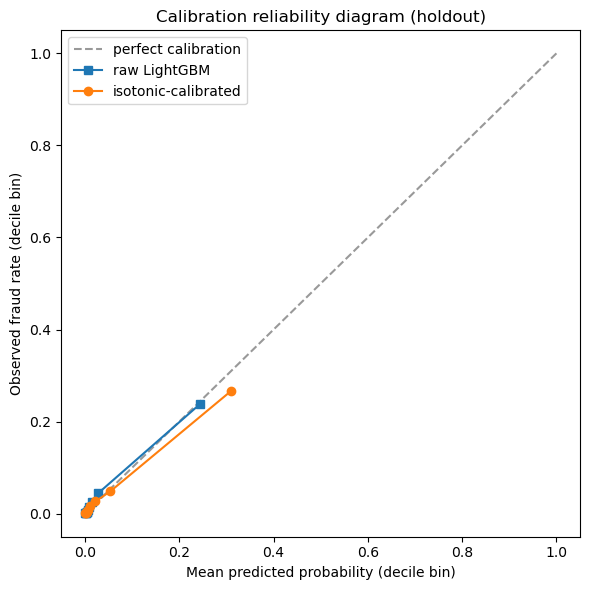

raw:  mean_pred = [0.001 0.002 0.002 0.003 0.005 0.006 0.009 0.014 0.028 0.244] | frac_pos = [0.002 0.002 0.002 0.004 0.005 0.007 0.015 0.025 0.045 0.238]
cal:  mean_pred = [0.001 0.002 0.002 0.004 0.005 0.007 0.011 0.022 0.054 0.311] | frac_pos = [0.002 0.002 0.003 0.005 0.005 0.009 0.016 0.027 0.049 0.267]


In [17]:
from sklearn.calibration import calibration_curve

y_ho = y[is_ho]
raw_ho = score_gbm_raw[is_ho]
cal_ho = score_gbm_cal[is_ho]

#groups holdout rows into 10 bins by predicted score and compares the average predicted probability in each bin to the fraud rate in that bin
frac_pos_raw, mean_pred_raw = calibration_curve(y_ho, raw_ho, n_bins=10, strategy='quantile')
frac_pos_cal, mean_pred_cal = calibration_curve(y_ho, cal_ho, n_bins=10, strategy='quantile')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, marker='s', label='raw LightGBM')
ax.plot(mean_pred_cal, frac_pos_cal, marker='o', label='isotonic-calibrated')
ax.set_xlabel('Mean predicted probability (decile bin)')
ax.set_ylabel('Observed fraud rate (decile bin)')
ax.set_title('Calibration reliability diagram (holdout)')
ax.legend()
plt.tight_layout()
plt.savefig(PRED_DIR / 'figures' / 'calibration_reliability.png', dpi=110)
plt.show()
print('raw:  mean_pred =', mean_pred_raw.round(3), '| frac_pos =', frac_pos_raw.round(3))
print('cal:  mean_pred =', mean_pred_cal.round(3), '| frac_pos =', frac_pos_cal.round(3))

The raw LightGBM probabilities are already fairly close to calibrated in most bins (log-loss-trained GBMs often are, unlike e.g. SVMs or uncalibrated random forests), and isotonic calibration does not uniformly help, as in the top decile it is actually slightly overconfident (predicted 0.311 vs. observed 0.267), while raw was closer there (0.244 vs. 0.238). 

Across the lower/middle deciles isotonic tracks the diagonal a bit more tightly than raw. With one bin where it overshoots, worth watching if this model is recalibrated periodically in production.

### Feature importance (LightGBM)
`importance_gain` sums the total reduction in loss each feature contributed across every split that used it (a better measure of how useful a feature actually was than `importance_split`, which just counts how often it was used regardless of how much that particular split helped). 
The table is sorted by gain for that reason.

In [18]:
feature_importance = pd.DataFrame({
    'feature': gbm_feats,
    'importance_gain': lgb_model.booster_.feature_importance('gain'), #gain=how much this feature improved the model's splits 

    'importance_split': lgb_model.booster_.feature_importance('split'), #split=how many times it was used to split

}).sort_values('importance_gain', ascending=False)

feature_importance.to_csv(PRED_DIR / 'lgb_feature_importance.csv', index=False)
feature_importance.head(15)

,feature,importance_gain,importance_split
12,C1,55347.492049,503
24,C14,32240.590613,316
23,C13,31318.384368,675
14,C4,28423.676263,61
0,TransactionDT,17875.535794,1476
27,D3,15487.884152,354
17,C7,15318.064130,27
1,TransactionAmt,14849.592611,1477
120,uid2_TransactionAmt_mean,14085.525193,1288
39,D15,13977.996087,967


`C1` is the single most important feature by gain, and it was already flagged back in Part 1's EDA as one of several C-block features showing a rising fraud rate across higher value deciles, so this is not a surprise reversal. 
The GBM is picking up the same signal that showed up early in EDA.

## Model comparison: holdout AUC and PR-AUC

`holdout` is the only split whose labels were never used for any fitting or selection decision (in Part 2's caveat on `val` being used once for V-block feature selection), it is the decision grade number. 

ROC-AUC is reported as a secondary, descriptive statistic; PR-AUC is the primary ranking-quality number given the ~3.4% base rate.

In [19]:
#collect all three models' scores in one place to compare
models = {
    'Isolation Forest': score_if,
    'Autoencoder': score_ae,
    'Calibrated LightGBM (supervised reference)': score_gbm_cal,
}

rows = []
for name, s in models.items():
    rows.append({
        'model': name,
        'val_auc': roc_auc_score(y[is_val], s[is_val]),  #val_auc is shown for reference
        'holdout_auc': roc_auc_score(y[is_ho], s[is_ho]),  #holdout_auc and holdout_pr_auc below are the real decision numbers
#since val was touched during fitting/calibration
        'holdout_pr_auc': average_precision_score(y[is_ho], s[is_ho]),
    })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(PRED_DIR / 'model_summary.csv', index=False)
summary_df

,model,val_auc,holdout_auc,holdout_pr_auc
0,Isolation Forest,0.698258,0.679052,0.057655
1,Autoencoder,0.718644,0.695858,0.069479
2,Calibrated LightGBM (supervised reference),0.933429,0.904952,0.484757


Both unsupervised detectors show a real, if modest, lift over the 3.4% base rate (PR-AUC ~1.7-2x base rate) using no label information whatsoever. 

The calibrated supervised reference is substantially stronger, which is expected, as it is included as context for when labels are available, not as a reason to abandon the unsupervised approach when they are not.

## Precision@K / Recall@K on the holdout window

For each day in the `holdout` window, transactions are ranked by score and only the top-K are treated as alerted.
Precision@K is the fraction of those alerts that are true fraud, Recall@K is the fraction of that day's total fraud captured. 

Reported for K=50, 100, 200 and for a fixed alert-rate variant that scales K with each day's actual volume. 

`alerts_per_1000txn` and `analyst_hours_per_day` (assuming 8 minutes of reviewer time per alert) translate the statistical metric into an operational one.

In [23]:
MIN_PER_ALERT = 8  #assuming analyst review time per alert in min

gbm_df['day'] = gbm_df['event_time'].dt.date
#build one table with the day, true label, and all three models's scores, so everything below can work off a single dataframe
holdout_eval = pd.DataFrame({
    'day': gbm_df.loc[is_ho, 'day'].values,
    'isFraud': y[is_ho],
    'Isolation Forest': score_if[is_ho],
    'Autoencoder': score_ae[is_ho],
    'Calibrated LightGBM (supervised reference)': score_gbm_cal[is_ho],
})
print(f"holdout window: {holdout_eval['day'].min()} to {holdout_eval['day'].max()}, "
      f"{holdout_eval['day'].nunique()} days, {len(holdout_eval)} transactions, "
      f"base fraud rate={holdout_eval['isFraud'].mean():.4f}")

#for each day takes the top-k highest-scored transactions as alerts and checks how many were actually fraud (precision) 
#and what share of that day's fraud they caught (recall)
def precision_recall_at_k(data, score_col, k):
    rows = []
    for d, g in data.groupby('day'):
        #that day's top-k highest scored rows are treated as the alerts
        topk = g.sort_values(score_col, ascending=False).head(k)
        n_fraud_day = g['isFraud'].sum()
        rows.append({
            'day': d, 'n_txn': len(g), 'n_fraud': n_fraud_day, 'alerts': len(topk),
            'precision_at_k': topk['isFraud'].sum() / len(topk) if len(topk) else np.nan,
            'recall_at_k': topk['isFraud'].sum() / n_fraud_day if n_fraud_day > 0 else np.nan,
        })
    return pd.DataFrame(rows)

pk_rows = []
for name in models:
    for k in [50, 100, 200]:
        r = precision_recall_at_k(holdout_eval, name, k)
        #converts the raw alert count k into a rate per 1000 transactions, so budgets are comparable across days with different volume
        alerts_per_1000 = 1000 * k / r.n_txn.mean()
        #converts alert count into hours of review time per day (the 8 min per alert assumption)
        analyst_hours = k * MIN_PER_ALERT / 60
        pk_rows.append({'model': name, 'k_type': 'fixed_K', 'k': k,
                         'mean_precision_at_k': r.precision_at_k.mean(),
                         'mean_recall_at_k': r.recall_at_k.mean(),
                         'alerts_per_1000txn': alerts_per_1000,
                         'analyst_hours_per_day': analyst_hours})

holdout window: 2018-04-21 to 2018-06-01, 42 days, 118108 transactions, base fraud rate=0.0344


In [24]:
pk_display = pk_df.drop(columns='k_type').rename(columns={ #column renaming for a shorter name
    'k': 'K',
    'mean_precision_at_k': 'P@K',
    'mean_recall_at_k': 'R@K',
    'alerts_per_1000txn': 'alerts/1000txn',
    'analyst_hours_per_day': 'analyst-hrs/day',
})
#rounding is for display only, the underlying numbers used elsewhere are unrounded
pk_display[['P@K', 'R@K']] = pk_display[['P@K', 'R@K']].round(3)
pk_display[['alerts/1000txn', 'analyst-hrs/day']] = pk_display[['alerts/1000txn', 'analyst-hrs/day']].round(1)
pk_display

,model,K,P@K,R@K,alerts/1000txn,analyst-hrs/day
0,Isolation Forest,50,0.071,0.038,17.8,6.7
1,Isolation Forest,100,0.070,0.074,35.6,13.3
2,Isolation Forest,200,0.072,0.150,71.1,26.7
3,Autoencoder,50,0.102,0.055,17.8,6.7
4,Autoencoder,100,0.098,0.103,35.6,13.3
5,Autoencoder,200,0.096,0.199,71.1,26.7
6,Calibrated LightGBM (supervised reference),50,0.673,0.353,17.8,6.7
7,Calibrated LightGBM (supervised reference),100,0.469,0.486,35.6,13.3
8,Calibrated LightGBM (supervised reference),200,0.303,0.626,71.1,26.7


At a fixed 50-alert daily budget, the Autoencoder catches only about 5% of that day's fraud at ~10% precision, purely unsupervised. 

The calibrated reference is dramatically stronger at the same budget (67% precision, 35% recall), this is the expected gap between an unsupervised anomaly ranker and a model that has actually seen fraud labels.

### Fixed alert-rate variant (K scales with each day's volume)

In [28]:
rate_rows = []
for name in models:
    #tests three alert-rate thresholds (0.5%, 1%, 2%) of each day's transactions
    for rate in [0.005, 0.01, 0.02]:
        rows = []
        for d, g in holdout_eval.groupby('day'):
            #turns a fixed percentage (like 1%) into a number of alerts for that specific day (daily transaction volume is not constant)
            k_d = max(1, int(round(rate * len(g))))
            #that day's top k_d alerts by score
            topk = g.sort_values(name, ascending=False).head(k_d)
            n_fraud_day = g['isFraud'].sum()
            #same precision/recall calc as the fixed-K version, but the alert count now scales with that day's volume
            rows.append({
                'alerts': k_d, 'n_txn': len(g),
                'precision_at_k': topk['isFraud'].sum() / len(topk) if len(topk) else np.nan,
                'recall_at_k': topk['isFraud'].sum() / n_fraud_day if n_fraud_day > 0 else np.nan,
            })
        r = pd.DataFrame(rows)
        #averages precision/recall across all holdout days for this model and rate
        rate_rows.append({'model': name, 'k_type': f'rate_{rate}', 'alert_rate': rate,
                           'mean_precision_at_k': r.precision_at_k.mean(),
                           'mean_recall_at_k': r.recall_at_k.mean(),
                           'avg_alerts_per_day': r.alerts.mean(),
                           'analyst_hours_per_day': r.alerts.mean() * MIN_PER_ALERT / 60})

In [29]:
#same cleanup as the fixed-K table above, just for the rate-based version
rate_display = rate_df.drop(columns='k_type').rename(columns={
    'alert_rate': 'rate',
    'mean_precision_at_k': 'P@K',
    'mean_recall_at_k': 'R@K',
    'avg_alerts_per_day': 'avg alerts/day',
    'analyst_hours_per_day': 'analyst-hrs/day',
})
#turns 0.01 into the string 1.0% for a more readable table
rate_display['rate'] = (rate_display['rate'] * 100).round(1).astype(str) + '%'
rate_display[['P@K', 'R@K']] = rate_display[['P@K', 'R@K']].round(3)
rate_display['avg alerts/day'] = rate_display['avg alerts/day'].round(0).astype(int)
rate_display['analyst-hrs/day'] = rate_display['analyst-hrs/day'].round(1)
rate_display

,model,rate,P@K,R@K,avg alerts/day,analyst-hrs/day
0,Isolation Forest,0.5%,0.080,0.011,14,1.9
1,Isolation Forest,1.0%,0.066,0.019,28,3.8
2,Isolation Forest,2.0%,0.072,0.041,56,7.5
3,Autoencoder,0.5%,0.112,0.017,14,1.9
4,Autoencoder,1.0%,0.108,0.032,28,3.8
5,Autoencoder,2.0%,0.103,0.060,56,7.5
6,Calibrated LightGBM (supervised reference),0.5%,0.877,0.132,14,1.9
7,Calibrated LightGBM (supervised reference),1.0%,0.813,0.244,28,3.8
8,Calibrated LightGBM (supervised reference),2.0%,0.643,0.377,56,7.5


At the tightest budget (0.5% alert rate, ~14 alerts/day), the calibrated reference reaches 88% precision but only 13% recall, very few alerts, but almost all of them correct. Loosening to 2.0% roughly quadruples the alert volume and recall (to 38%) at the cost of precision dropping to 64%. The unsupervised detectors stay well below the reference at every rate, peaking around 11% precision at the tightest (0.5%) budget and drifting slightly lower as the rate loosens.

### Precision@K/Recall@K curves and workload trade-off

The tables above only show three point estimates (K=50/100/200). This sweeps a wider range of K and plots the full curve, plus a workload-framed view (recall vs. analyst-hours/day instead of the more abstract K).

                                     model  k  precision_at_k  recall_at_k  analyst_hours_per_day
                          Isolation Forest 10          0.0810       0.0086                 1.3333
                          Isolation Forest 20          0.0726       0.0153                 2.6667
                          Isolation Forest 30          0.0706       0.0230                 4.0000
                          Isolation Forest 50          0.0710       0.0380                 6.6667
                               Autoencoder 10          0.1119       0.0130                 1.3333
                               Autoencoder 20          0.1048       0.0234                 2.6667
                               Autoencoder 30          0.1056       0.0356                 4.0000
                               Autoencoder 50          0.1019       0.0547                 6.6667
Calibrated LightGBM (supervised reference) 10          0.8786       0.0954                 1.3333
Calibrated LightGBM 

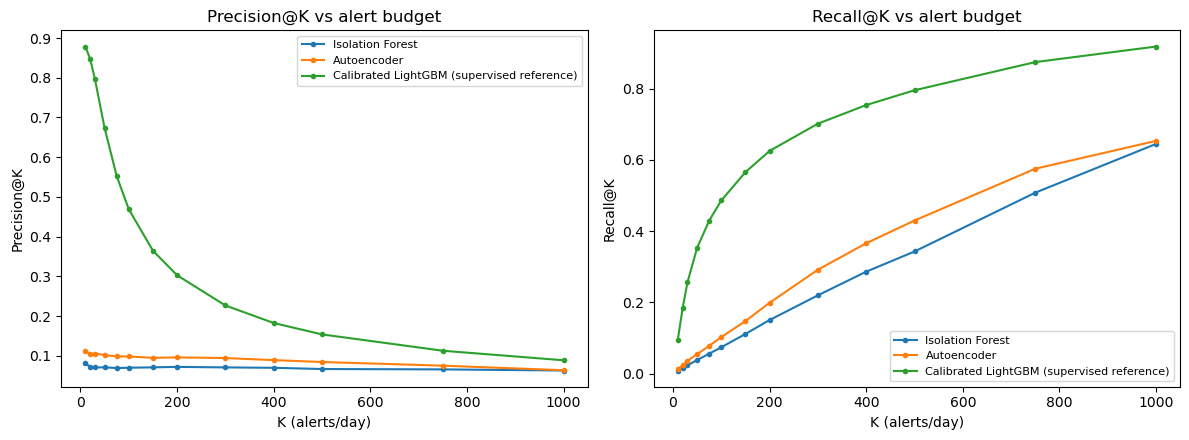

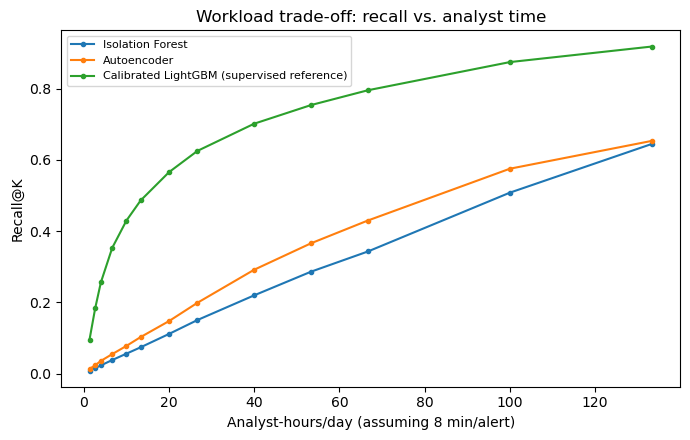

In [31]:
#sweeps across a wide range of alert budgets to see how precision/recall trade off as the budget grows
K_grid = [10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500, 750, 1000]

curve_rows = []
for name in models:
    for k in K_grid:
        r = precision_recall_at_k(holdout_eval, name, k)
        curve_rows.append({'model': name, 'k': k,
                            'precision_at_k': r.precision_at_k.mean(),
                            'recall_at_k': r.recall_at_k.mean(),
                            'analyst_hours_per_day': k * MIN_PER_ALERT / 60})
#one row per model per K, ready to both save as csv and plot below
curve_df = pd.DataFrame(curve_rows)
curve_df.to_csv(PRED_DIR / 'precision_recall_at_k_curves.csv', index=False)
#just prints a few K values before plotting the full curve
check_k = [10, 20, 30, 50]
check_cols = ['model', 'k', 'precision_at_k', 'recall_at_k', 'analyst_hours_per_day']
print(curve_df[curve_df.k.isin(check_k)][check_cols].round(4).to_string(index=False))

#left plot (precision vs K)
#right plot (recall vs K, one line per model)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in models:
    sub = curve_df[curve_df.model == name]
    axes[0].plot(sub.k, sub.precision_at_k, marker='o', ms=3, label=name)
    axes[1].plot(sub.k, sub.recall_at_k, marker='o', ms=3, label=name)
axes[0].set_xlabel('K (alerts/day)'); axes[0].set_ylabel('Precision@K'); axes[0].set_title('Precision@K vs alert budget')
axes[1].set_xlabel('K (alerts/day)'); axes[1].set_ylabel('Recall@K'); axes[1].set_title('Recall@K vs alert budget')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(PRED_DIR / 'figures' / 'precision_recall_at_k_curves.png', dpi=110)
plt.show()

#same recall values as above, but the x-axis is analyst hours instead of K(easier to compare)
fig, ax1 = plt.subplots(figsize=(7, 4.5))
for name in models:
    sub = curve_df[curve_df.model == name]
    ax1.plot(sub.analyst_hours_per_day, sub.recall_at_k, marker='o', ms=3, label=name)
ax1.set_xlabel('Analyst-hours/day (assuming 8 min/alert)'); ax1.set_ylabel('Recall@K')
ax1.set_title('Workload trade-off: recall vs. analyst time'); ax1.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PRED_DIR / 'figures' / 'workload_tradeoff.png', dpi=110)
plt.show()

Both unsupervised curves are fairly flat and low across the whole K range (Precision@K roughly 0.07-0.11 for Isolation Forest and 0.10-0.11 for the Autoencoder, regardless of budget), while the calibrated reference's precision decays smoothly from ~0.88 at K=10 down toward the base rate as K grows into the hundreds, so the expected shape for a model with real discriminative signal being asked to rank increasingly deep into the pool. 

The workload plot makes the marginal-return trade-off explicit, by doubling the alert budget from K=10 to K=20 (1.3 to 2.7 analyst-hours/day) roughly doubles the calibrated reference's recall too (0.095 to 0.184), while the same change barely moves the unsupervised detectors in absolute terms (Isolation Forest 0.9% to 1.5%, Autoencoder 1.3% to 2.3%).

### Temporal stability and re-calibration needs across the holdout window

Parts 1-2 already established that fraud rate and several feature distributions drift over the data's timespan (weekly fraud-rate plots, PSI), so it matters whether that drift actually degrades the trained models rather than just being a property of the raw data. 

This splits the 42-day holdout window into its 6 constituent weeks and tracks Precision@100 (calibrated reference) and the mean-predicted vs observed calibration gap week by week (a lightweight diagnostic rather than a full rolling-retrain experiment).

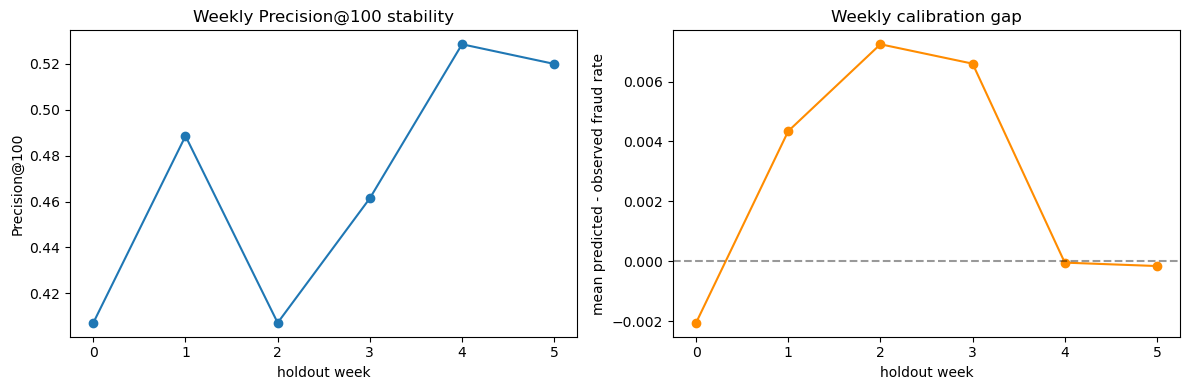

,week,n_days,n_txn,precision_at_100,recall_at_100,mean_calibrated_score,observed_fraud_rate,calibration_gap
0,0,7,18123,0.407143,0.461706,0.032706,0.034762,-0.002057
1,1,7,21443,0.488571,0.513851,0.035124,0.030779,0.004344
2,2,7,19811,0.407143,0.501812,0.035765,0.028520,0.007245
3,3,7,21038,0.461429,0.444980,0.041249,0.034652,0.006597
4,4,7,19941,0.528571,0.513458,0.036711,0.036758,-0.000047
5,5,7,17752,0.520000,0.482091,0.041919,0.042080,-0.000161


In [32]:
#the day column to a real datetime so week numbers can be calculated
holdout_eval['date'] = pd.to_datetime(holdout_eval['day'])
#split the holdout window into 7-day chunks, numbered from 0 as the first day
holdout_eval['week'] = (holdout_eval['date'] - holdout_eval['date'].min()).dt.days // 7

weekly_rows = []
#checks calibrated GBM's performance and calibration separately for each week, to see if either degrades over time
for wk, g in holdout_eval.groupby('week'):
    #precision/recall at a fixed 100 alerts/day, using only this week's rows
    r = precision_recall_at_k(g, 'Calibrated LightGBM (supervised reference)', 100)
    #average predicted probability this week
    mean_pred = g['Calibrated LightGBM (supervised reference)'].mean()
    obs_rate = g['isFraud'].mean() ##fraud rate this week
    weekly_rows.append({
        'week': int(wk), 'n_days': g['day'].nunique(), 'n_txn': len(g),
        'precision_at_100': r.precision_at_k.mean(), 'recall_at_100': r.recall_at_k.mean(),
        'mean_calibrated_score': mean_pred, 'observed_fraud_rate': obs_rate,
        #calibration_gap is how far off the model's average predicted probability is from the actual fraud rate that week
        ###near zero means the model stayed well calibrated over time
        'calibration_gap': mean_pred - obs_rate,
    })
    
weekly_df = pd.DataFrame(weekly_rows)#one row per week
weekly_df.to_csv(PRED_DIR / 'weekly_stability.csv', index=False)

#left plot (does precision hold steady week to week)
#right plot (does the calibration gap drift away from zero)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weekly_df.week, weekly_df.precision_at_100, marker='o')
axes[0].set_xlabel('holdout week'); axes[0].set_ylabel('Precision@100'); axes[0].set_title('Weekly Precision@100 stability')
axes[1].plot(weekly_df.week, weekly_df.calibration_gap, marker='o', color='darkorange')
axes[1].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[1].set_xlabel('holdout week'); axes[1].set_ylabel('mean predicted - observed fraud rate')
axes[1].set_title('Weekly calibration gap')
plt.tight_layout()
plt.savefig(PRED_DIR / 'figures' / 'weekly_stability.png', dpi=110)
plt.show()
weekly_df

Precision@100 ranges 0.41-0.53 across the six holdout weeks, it is noisy at this sample size (only ~100 alerts/day x 7 days per week) but with no clear downward trend; if anything the last two weeks are the strongest. 

The calibration gap stays small throughout (between -0.0021 and +0.0072, under a percentage point of the true fraud rate every week). 

Over this ~6-week holdout horizon there is no evidence the calibrated reference needs recalibration (performance and calibration both hold up). This is useful negative result, it should be rechecked periodically since 6 weeks is a short horizon.

## SHAP explainability (calibrated reference model)

Global SHAP importance plus short case notes on individual `holdout` alerts, computed for the calibrated LightGBM reference via `TreeExplainer` (exact and fast for tree ensembles, no KernelExplainer approximation needed). Computed on a random sample of 4000 holdout rows for speed.

In [35]:
rng = np.random.RandomState(0)
sample_idx = rng.choice(np.where(is_ho)[0], size=4000, replace=False) #randomly picks 4000 row positions from the holdout set only
X_sample = Xg.iloc[sample_idx] #the feature rows for just those sampled transactions
#keeps the transaction IDs for the same rows, so results can be traced back to specific transactions
tid_sample = gbm_df['TransactionID'].values[sample_idx]
y_sample = y[sample_idx]
cal_sample = score_gbm_cal[sample_idx]

explainer = shap.TreeExplainer(lgb_model) #SHAP explainer specific to the trained LightGBM model
#how much each feature pushed each transaction's score up or down
shap_values = explainer.shap_values(X_sample) #picks out the fraud class array 
shap_values = shap_values[1] if isinstance(shap_values, list) else shap_values

#averages the absolute SHAP impact of each feature across all sampled rows, as one overall importance ranking
global_importance = pd.DataFrame({
    'feature': gbm_feats,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
global_importance.to_csv(PRED_DIR / 'shap_global_importance.csv', index=False)
global_importance.head(15)

,feature,mean_abs_shap
15,C5,0.266011
23,C13,0.256410
0,TransactionDT,0.240719
1,TransactionAmt,0.160244
12,C1,0.148080
94,card6,0.131254
43,M4,0.127084
24,C14,0.117339
26,D2,0.111077
39,D15,0.097474


top 10 by mean SHAP: C5, C13, TransactionDT, TransactionAmt, C1, card6, M4, C14, D2, D15. 

C-block features (anonymized counting features) make up much of the top 10, alongside calendar/amount signal (`TransactionDT`, `TransactionAmt`) and a couple of D-block (time-delta) features, broadly consistent with Part 2's V-block mutual information screen showing that engineered/derived signal outperforms raw columns, though that screen only covered V-block features specifically, not C or D. 

SHAP confirms these features actually drive the trained model's decisions, not just their marginal association with the label.

### SHAP summary plot
The table above ranks features by average SHAP but says nothing about direction, this beeswarm plot shows, for each holdout transaction, how much that feature pushed the score up or down (x-axis: SHAP value) and whether it did so at a high or low value of that feature. 

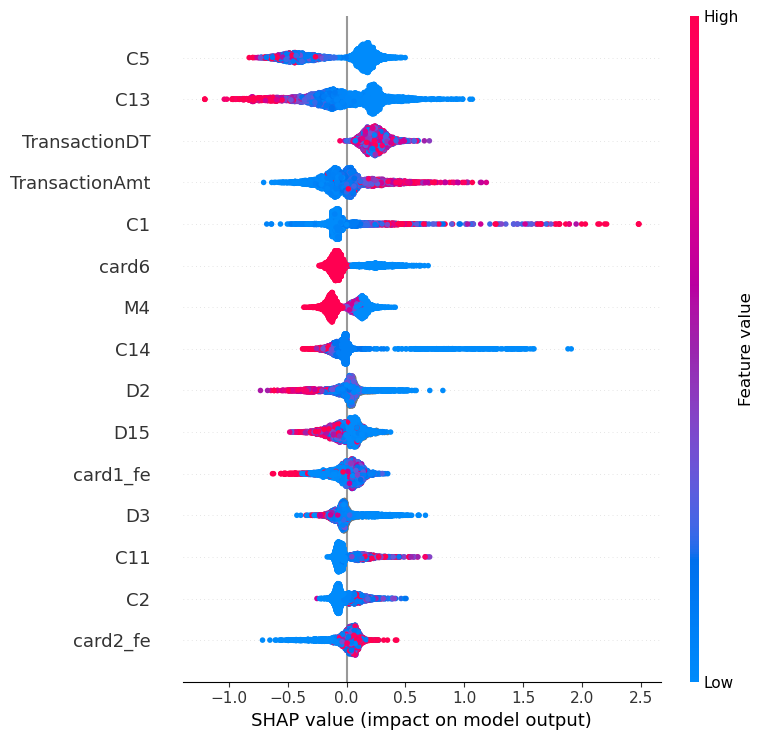

In [34]:
#top 15 features ranked by SHAP impact
#color red = high, blue = low
shap.summary_plot(shap_values, X_sample, feature_names=gbm_feats, max_display=15, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig(PRED_DIR / 'shap_summary_plot.png', dpi=110, bbox_inches='tight')
plt.show()

`C1` shows the clearest pattern, where high values (red) push the calibrated score sharply upward for a subset of transactions (the long red tail out to +2.5), while low values (blue) stay close to baseline. 

`TransactionAmt` shows a similar, noisier rightward tail at higher amounts, consistent with the earlier finding that the highest amount decile carries a disproportionate share of total fraud. 

Not every top feature is this clean, though C5 and C13 show mixed colors on both sides rather than a smooth gradient, meaning their relationship with the model's output is not simply higher value, higher risk. For label-encoded categoricals like `card6` and `M4`, color marks which category a transaction falls into rather than a meaningful high/low value (the two color clusters are not ordered, since label encoding assigns arbitrary integers to categories for the tree model rather than a real scale).

### Case notes: top scored true-fraud alerts in the holdout sample

For the highest scored true-fraud alerts in the sample, this shows which features actually drove each individual prediction, the per-case complement to the global importance ranking above. 

In [36]:
#sorts the sampled transactions from highest to lowest calibrated score
case_order = np.argsort(-cal_sample)
cases = []
for i in case_order:
    #picks the first 3 transactions in that order that were actually fraud, to use as example case notes
    if y_sample[i] == 1 and len(cases) < 3:
        row_shap = shap_values[i] #this transaction's own SHAP values, one per feature
        #the 5 features that pushed this transaction's score the most, in either direction
        top_feats = np.argsort(-np.abs(row_shap))[:5]
        cases.append({
            'TransactionID': int(tid_sample[i]),
            'calibrated_score': float(cal_sample[i]),
            'true_label': 'fraud',
            'top_drivers': [{'feature': gbm_feats[j], 'shap_value': float(row_shap[j])} for j in top_feats],
        })

(PRED_DIR / 'shap_case_notes.json').write_text(json.dumps(cases, indent=2)) #saving cases so they can be referenced later without rerunning
#prints each case's top drivers
for c in cases:
    print(f"\nTransactionID {c['TransactionID']}  |  calibrated score = {c['calibrated_score']:.3f}")
    for d in c['top_drivers']:
        print(f"    {d['feature']:>18s}  shap={d['shap_value']:+.3f}")


TransactionID 3480693  |  calibrated score = 1.000
                   C14  shap=+1.909
                   C13  shap=+0.962
                    C1  shap=+0.956
        TransactionAmt  shap=+0.950
                   C11  shap=+0.689

TransactionID 3492819  |  calibrated score = 1.000
                    C1  shap=+1.547
                   C14  shap=+1.133
                   C13  shap=+1.068
                   C11  shap=+0.567
                    C4  shap=+0.538

TransactionID 3577092  |  calibrated score = 0.944
                    C1  shap=+1.658
          Vgrp009_pca1  shap=+0.545
          Vgrp003_pca1  shap=+0.540
         DeviceInfo_fe  shap=+0.443
                   C13  shap=+0.410


For each of the top 3, the calibrated score and its top 5 SHAP drivers are printed and saved to `shap_case_notes.json`.

example case note (TransactionID 3480693): calibrated score 1.00, top SHAP drivers `C14` (+1.91), `C13` (+0.96), `C1` (+0.96), `TransactionAmt` (+0.95), `C11` (+0.69) (an unusually high `C14`/`C13`/`C1` combination (the anonymized counting features associated with entity/device repetition) together with the transaction amount are what push this specific alert's score toward 1.0). 

This kind of breakdown gives a concrete rationale for the alert even without knowing what `C14` literally represents.

### GBM vs. Autoencoder alert overlap

Reserving part of the daily alert budget for transactions the Autoencoder ranks highly but the calibrated GBM does not, could be a way to combine the two models' strengths. This idea is just an assumption in this case, so it needed to be checked against real holdout data, at each budget K, how much do the two models' top-K sets actually overlap, and does the Autoencoder-only slice actually contain fraud the GBM would have missed.

In [37]:
overlap_rows = []
for k in [50, 100, 200]: #checks overlap at three different alert budgets
    day_rows = []
    for d, g in holdout_eval.groupby('day'): #gets the row indexes of that day's top-k alerts for each model, so they can be compared as sets
        top_gbm = set(g.sort_values('Calibrated LightGBM (supervised reference)', ascending=False).head(k).index)
        top_ae = set(g.sort_values('Autoencoder', ascending=False).head(k).index)
        ae_only = top_ae - top_gbm #set difference (transactions the autoencoder would have flagged that the GBM's alert list does not include)
        ae_only_fraud = g.loc[list(ae_only), 'isFraud'].sum() if ae_only else 0 #how much real fraud is in that autoencoder-only slice
        day_rows.append({'overlap_n': len(top_gbm & top_ae), 'ae_only_n': len(ae_only), 'ae_only_fraud_n': ae_only_fraud})
    dd = pd.DataFrame(day_rows) #summarizes the day-by-day numbers into one row per k
    overlap_rows.append({
        'k': k,
        'mean_overlap_pct': (dd.overlap_n / k).mean(), #average share of the two models' alert lists that actually agree
        'mean_ae_only_alerts_per_day': dd.ae_only_n.mean(),
        'total_ae_only_fraud_found_in_holdout': int(dd.ae_only_fraud_n.sum()),
        #of the transactions only the autoencoder would have flagged, what share were actually fraud
        'ae_only_precision': dd.ae_only_fraud_n.sum() / dd.ae_only_n.sum() if dd.ae_only_n.sum() > 0 else np.nan,
    }) 
overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(PRED_DIR / 'gbm_ae_overlap.csv', index=False)
overlap_df

,k,mean_overlap_pct,mean_ae_only_alerts_per_day,total_ae_only_fraud_found_in_holdout,ae_only_precision
0,50,0.100952,44.952381,69,0.036547
1,100,0.150000,85.000000,84,0.023529
2,200,0.213929,157.214286,97,0.014690


The two models' top-K sets barely overlap (only 10-21% of alerts are shared, rising slowly with K). The Autoencoder is genuinely looking at different transactions. And it is not just noise, as across the 42-day holdout, the Autoencoder-only slice contained 69 additional true-fraud transactions at K=50, 84 at K=100, and 97 at K=200 that the calibrated GBM's same sized alert list would have missed entirely (at a lower per-alert precision than the GBM's own list, 1.5-3.7%, but non-zero and additive).

## Alert-budget recommendation for two staffing scenarios

After the previous steps this stage is ready to be discussed  

Translating the Precision@K/Recall@K table into a staffing decision. The two scenarios below are illustrative, the specific analyst-hours figures are not drawn from a real deployment, but the method for converting a review-capacity number into a K/alert-rate choice would carry over directly to one.

- Lean team (~2 hours/analyst/day available for fraud review, 1 analyst): budget ≈ 15 alerts/day -> closest to the rate=0.5% row.
- Expanded team (~4 analyst-hours/day, e.g. 2 analysts at 2h each, or 1 analyst at 4h): budget ≈ 30 alerts/day -> closest to the rate=1% row.

In [38]:
#two scenarios 
scenarios = {
    'Lean team (~2 analyst-hrs/day, ~15 alerts/day)': 15, #lean team reviewing 15 alerts/day,
    'Expanded team (~4 analyst-hrs/day, ~30 alerts/day)': 30, #expanded team reviewing 30/day
}

rec_rows = []
#runs the same precision/recall check for every model under each staffing scenario
for scenario, k_budget in scenarios.items():
    for name in models:
        r = precision_recall_at_k(holdout_eval, name, k_budget)
        rec_rows.append({
            'scenario': scenario, 'model': name, 'k_budget': k_budget,
            'mean_precision_at_k': round(r.precision_at_k.mean(), 3),
            'mean_recall_at_k': round(r.recall_at_k.mean(), 3),
            'analyst_hours_per_day': round(k_budget * MIN_PER_ALERT / 60, 1),
        })
#one row per scenario per model
rec_df = pd.DataFrame(rec_rows)
rec_df.to_csv(PRED_DIR / 'alert_budget_recommendation.csv', index=False)
rec_df

,scenario,model,k_budget,mean_precision_at_k,mean_recall_at_k,analyst_hours_per_day
0,"Lean team (~2 analyst-hrs/day, ~15 alerts/day)",Isolation Forest,15,0.081,0.013,2.0
1,"Lean team (~2 analyst-hrs/day, ~15 alerts/day)",Autoencoder,15,0.106,0.018,2.0
2,"Lean team (~2 analyst-hrs/day, ~15 alerts/day)",Calibrated LightGBM (supervised reference),15,0.875,0.142,2.0
3,"Expanded team (~4 analyst-hrs/day, ~30 alerts/...",Isolation Forest,30,0.071,0.023,4.0
4,"Expanded team (~4 analyst-hrs/day, ~30 alerts/...",Autoencoder,30,0.106,0.036,4.0
5,"Expanded team (~4 analyst-hrs/day, ~30 alerts/...",Calibrated LightGBM (supervised reference),30,0.796,0.256,4.0


At either budget, the calibrated LightGBM model should drive the primary daily alert queue. Its precision is far higher than either unsupervised model at the same analyst-hours cost - 0.875 versus 0.081 (Isolation Forest) and 0.106 (Autoencoder) at the lean-team budget, and 0.796 versus 0.071 and 0.106 at the expanded-team budget, so reviewer time is best spent there first.

Isolation Forest and the Autoencoder are better used as a secondary, label-independent check rather than the main ranking source. The Autoencoder's top-K alerts overlap with the GBM's by only 10-21%, and the slice it flags that the GBM misses still contains 69-97 additional true-fraud transactions across the 42-day holdout, fraud the GBM's alert list never surfaced.

A simple policy is to fill the daily budget mainly from the calibrated GBM ranking, and set aside a small fixed slice (for example, 10-20% of the budget) for transactions that rank high for the Autoencoder but not for the GBM. This means accepting a much lower hit rate on that slice, closer to the Autoencoder's own precision than the GBM's, in exchange for catching fraud the GBM's ranking would likely never surface, regardless of budget size. That segment is also where drift or patterns the supervised model has not learned would be expected to show up first.

Both scenarios assume 8 minutes per alert. If the real per case review time is different, `analyst_hours_per_day` rescales linearly, and the K-to-budget mapping would need to be redone with the correct number.

## Modeling conclusions

- **Isolation Forest** and a **tabular Autoencoder** are the primary detectors, trained without ever touching `isFraud`. On the holdout set, PR-AUC is 0.058 for Isolation Forest and 0.070 for the Autoencoder, against a 3.4% base rate, a modest but real lift without using any labels. The Autoencoder does better here, plausibly because it can capture nonlinear feature interactions that the axis-aligned Isolation Forest partly misses.
- The **calibrated LightGBM model** (a single model, isotonic-calibrated, not blended) reaches holdout AUC 0.9050 and PR-AUC 0.4848, clearly the strongest ranker when labels are available. It is used here only as a reference point, not as the project's main model.
- Precision@K, Recall@K, alerts-per-1000-transactions, and analyst-hours are all computed on real model scores over the `holdout` window, not the toy `TransactionAmt`as-score illustration from Part 1. Numbers are reported for K = 50/100/200 and for fixed alert-rate variants, which gives a fuller picture than a single aggregate AUC number.
- SHAP shows that `C`block engineered features are among the strongest drivers of the reference model's decisions, along with calendar/amount signal and a couple of `D`-block features. This is broadly consistent with Part 2's mutual-information screen, where engineered/derived features outperformed raw columns, though that screen looked at `V`-block features specifically, not `C`/`D`. Per-alert case notes also give a short, reviewable explanation for individual flagged transactions.
- The weekly temporal-stability check on the holdout window shows no clear decay in Precision@100 or drift in calibration over the 6 week horizon.
- Precision@K/Recall@K curves and a workload trade-off plot (recall vs. analyst-hours per day) show how these metrics behave across the full range of alert budgets, rather than at only three fixed points.
- The GBM vs. Autoencoder overlap analysis shows the two models flag largely different transactions (10-21% overlap). The Autoencoder-only slice still contains real fraud (69 to 97 cases across the holdout), that the GBM's alert list misses entirely.
- The final alert-budget recommendation treats the calibrated GBM as the primary ranking source, and proposes reserving a fixed slice of the daily budget for transactions the Autoencoder flags but the GBM does not, since those alerts do catch real fraud.